<div style = "text-align: center">
    <img src = "Banner.png" width = "100%" style = "border: solid; border-radius: 10px"></img>
</div>

<h1 style = 'text-align: center;'>Problemas de Fluxos em Redes:<br>Resolvendo o Problema do Caminho Mínimo</h1>

por **Elias Helou**

**ICMC/USP - São Carlos SP**

<h2>Conteúdo do Vídeo</h2>

1. Algoritmos para o problema do caminho mínimo

2. Resolvendo com o `NetworkX`

3. Resolvendo com otimização linear

## 1. Algoritmos para o Problema do Caminho Mínimo

Nós já vimos que é possível formular o problema do caminho mínimo como um problema de otimização matemática binária e relaxar esse modelo como um problema de otimização linear.

Entretanto, existem métodos muito mais eficientes para resolver esse problema. As aplicações são evidentes, as variantes são muitas e os ambientes computacionais, os mais variados. Por este motivo, diversos algoritmos foram desenvolvidos.

<div style="text-align: center;">
 <iframe type="text/html" src="https://en.wikipedia.org/wiki/Shortest_path_problem" width="90%" height="400" style="text-align: center; border: solid; border-radius: 10px"> 
</div>

## 2. Resolvendo Usando o `NetworkX`

O pacote `NetworkX` possui funções para a solução do problema do caminho mínimo

<div style="text-align: center;">
 <iframe type="text/html" src="https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html" width="90%" height="700px" style="text-align: center; border: solid; border-radius: 10px;"> 
</div>

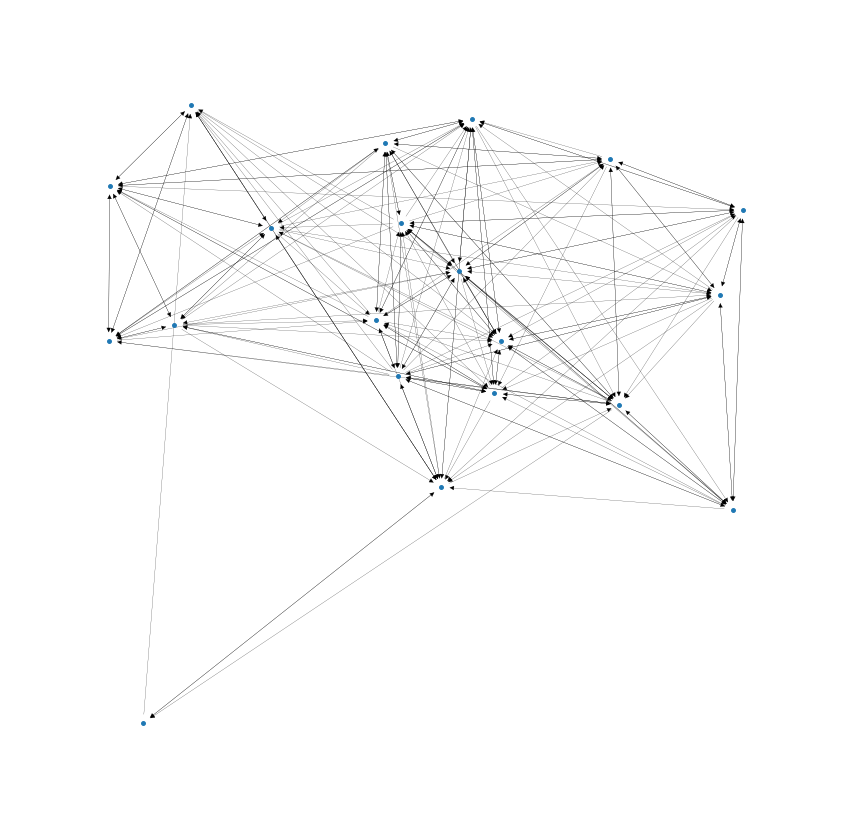

In [1]:
import networkx as nx
import matplotlib.pyplot as pp
import numpy as np

N = 20

# Gera N pontos aleatórios no quadrado [ 0, 1 ] x [ 0, 1 ]
np.random.seed( 0 )
pos = {}
for i in range( 1, N + 1 ):
    pos[ i ] = np.random.uniform( size = ( 2, ) )

# Conecta vértices com probabilidade proporcional à distância
G = nx.DiGraph()
for i in range( 1, N + 1 ):
    for j in range( 1, N + 1 ):
        d = (
            ( pos[ i ][ 0 ] - pos[ j ][ 0 ] ) ** 2 +
            ( pos[ i ][ 1 ] - pos[ j ][ 1 ] ) ** 2
        ) ** 0.5

        r = np.random.uniform()
        if ( i != j ) and ( d < r ):
            G.add_edge( i, j, weight = d )

pp.figure( figsize = ( 15, 15 ) )

nx.draw_networkx_nodes( G, pos, node_size = 15 )
nx.draw_networkx_edges( G, pos, width = 0.2 )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()


18 11


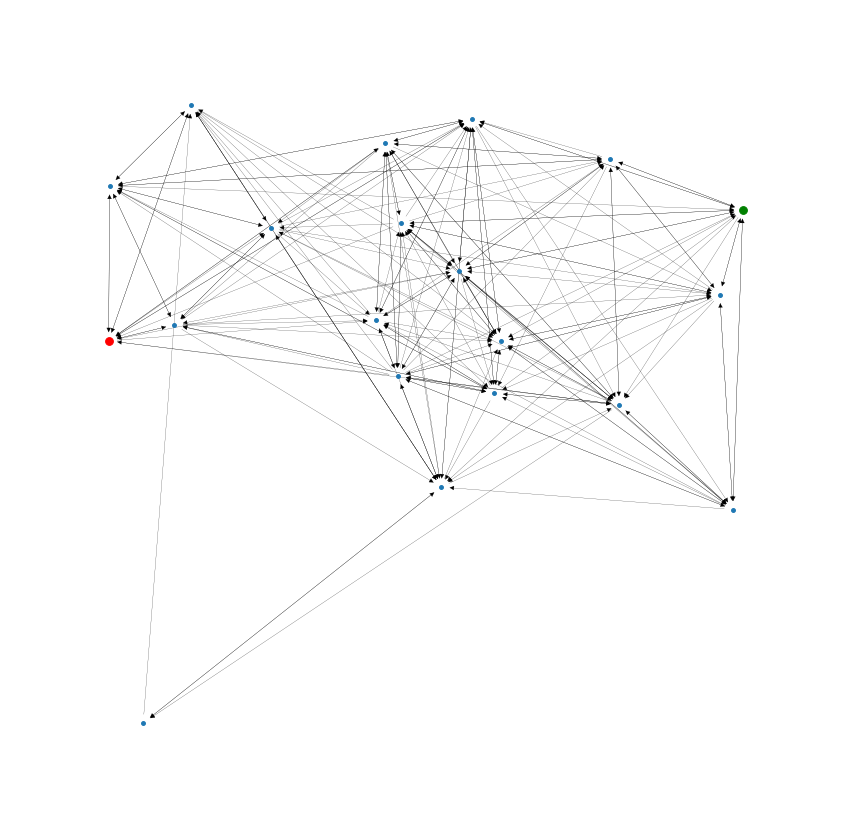

In [2]:
# Origem é o mais à esquerda
mn_x = np.inf
o = 0
for i in G.nodes:
    if pos[ i ][ 0 ] < mn_x:
        mn_x = pos[ i ][ 0 ]
        o = i

# Destino é o mais à direita
mx_x = -np.inf
d = 0
for i in G.nodes:
    if pos[ i ][ 0 ] > mx_x:
        mx_x = pos[ i ][ 0 ]
        d = i

print( o, d )

pp.figure( figsize = ( 15, 15 ) )

nx.draw_networkx_nodes( G, pos, node_size = 15 )
nx.draw_networkx_edges( G, pos, width = 0.2 )

pp.scatter( pos[ o ][ 0 ], pos[ o ][ 1 ], c = 'r', s = 60, zorder = 10 )
pp.scatter( pos[ d ][ 0 ], pos[ d ][ 1 ], c = 'g', s = 60, zorder = 10 )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()

In [3]:
cm = nx.shortest_path( G, o, d, 'weight' )
print( cm )

[18, 1, 11]


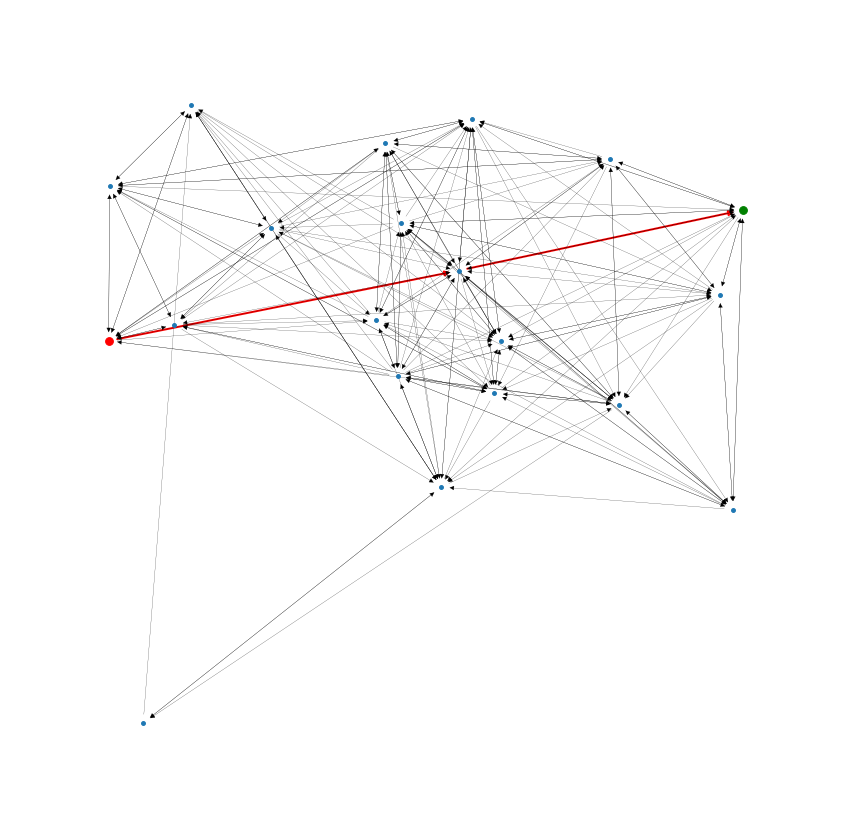

DiGraph with 20 nodes and 194 edges


In [4]:
el = []
for i in range( len( cm ) - 1 ):
    el.append( ( cm[ i ], cm[ i + 1 ] ) )

pp.figure( figsize = ( 15, 15 ) )

nx.draw_networkx_edges( G, pos, width = 2.0, edgelist = el, edge_color = 'r' )
nx.draw_networkx_nodes( G, pos, node_size = 15 )
nx.draw_networkx_edges( G, pos, width = 0.2 )

pp.scatter( pos[ o ][ 0 ], pos[ o ][ 1 ], c = 'r', s = 60, zorder = 10 )
pp.scatter( pos[ d ][ 0 ], pos[ d ][ 1 ], c = 'g', s = 60, zorder = 10 )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()

print( G )

Observe que

- A solução é obtida muito rapidamente

- O caminho possui poucas arestas, pois o grafo é relativamente *denso*

- Pode não haver caminho!

Vamos reduzir o número de arestas para exemplificar a segunda e a terceira observação:

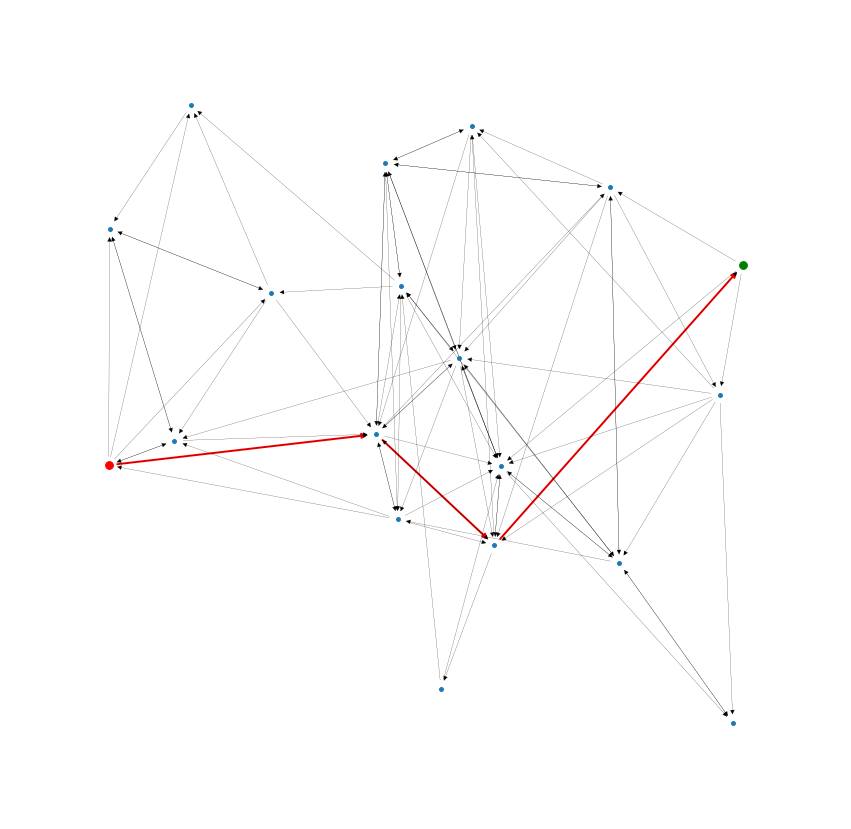

DiGraph with 19 nodes and 85 edges


In [5]:
import networkx as nx
import matplotlib.pyplot as pp
import numpy as np

N = 20

# Gera N pontos aleatórios no quadrado [ 0, 1 ] x [ 0, 1 ]
np.random.seed( 0 )
pos = {}
for i in range( 1, N + 1 ):
    pos[ i ] = np.random.uniform( size = ( 2, ) )

# Conecta vértices com probabilidade proporcional à distância
G = nx.DiGraph()
for i in range( 1, N + 1 ):
    for j in range( 1, N + 1 ):
        d = (
            ( pos[ i ][ 0 ] - pos[ j ][ 0 ] ) ** 2 +
            ( pos[ i ][ 1 ] - pos[ j ][ 1 ] ) ** 2
        ) ** 0.5

        r = np.random.uniform()
        if ( i != j ) and ( d < r / 2 ):
            G.add_edge( i, j, weight = d )

# Origem é o mais à esquerda
mn_x = np.inf
o = 0
for i in G.nodes:
    if pos[ i ][ 0 ] < mn_x:
        mn_x = pos[ i ][ 0 ]
        o = i

# Destino é o mais à direita
mx_x = -np.inf
d = 0
for i in G.nodes:
    if pos[ i ][ 0 ] > mx_x:
        mx_x = pos[ i ][ 0 ]
        d = i

cm = nx.shortest_path( G, o, d, 'weight' )

el = []
for i in range( len( cm ) - 1 ):
    el.append( ( cm[ i ], cm[ i + 1 ] ) )

pp.figure( figsize = ( 15, 15 ) )

nx.draw_networkx_edges( G, pos, width = 2.0, edgelist = el, edge_color = 'r' )
nx.draw_networkx_nodes( G, pos, node_size = 15 )
nx.draw_networkx_edges( G, pos, width = 0.2 )

pp.scatter( pos[ o ][ 0 ], pos[ o ][ 1 ], c = 'r', s = 60, zorder = 10 )
pp.scatter( pos[ d ][ 0 ], pos[ d ][ 1 ], c = 'g', s = 60, zorder = 10 )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()

print( G )

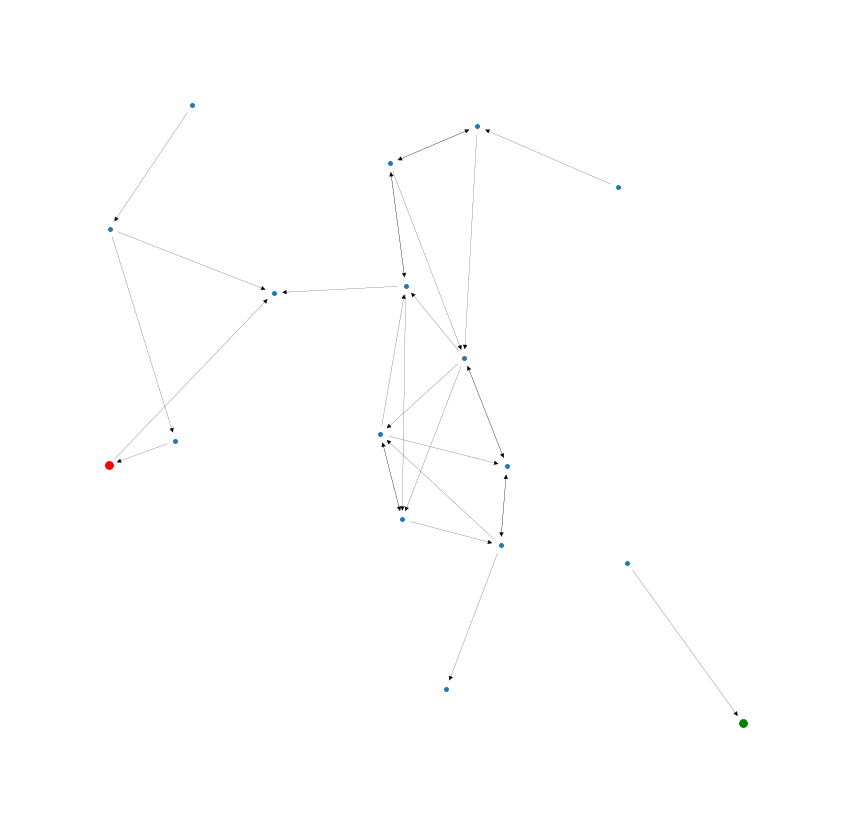

DiGraph with 17 nodes and 29 edges


In [6]:
import networkx as nx
import matplotlib.pyplot as pp
import numpy as np

N = 20

# Gera N pontos aleatórios no quadrado [ 0, 1 ] x [ 0, 1 ]
np.random.seed( 0 )
pos = {}
for i in range( 1, N + 1 ):
    pos[ i ] = np.random.uniform( size = ( 2, ) )

# Conecta vértices com probabilidade proporcional à distância
G = nx.DiGraph()
for i in range( 1, N + 1 ):
    for j in range( 1, N + 1 ):
        d = (
            ( pos[ i ][ 0 ] - pos[ j ][ 0 ] ) ** 2 +
            ( pos[ i ][ 1 ] - pos[ j ][ 1 ] ) ** 2
        ) ** 0.5

        r = np.random.uniform()
        if ( i != j ) and ( d < r / 3 ):
            G.add_edge( i, j, weight = d )

# Origem é o mais à esquerda
mn_x = np.inf
o = 0
for i in G.nodes:
    if pos[ i ][ 0 ] < mn_x:
        mn_x = pos[ i ][ 0 ]
        o = i

# Destino é o mais à direita
mx_x = -np.inf
d = 0
for i in G.nodes:
    if pos[ i ][ 0 ] > mx_x:
        mx_x = pos[ i ][ 0 ]
        d = i

pp.figure( figsize = ( 15, 15 ) )

nx.draw_networkx_nodes( G, pos, node_size = 15 )
nx.draw_networkx_edges( G, pos, width = 0.2 )

pp.scatter( pos[ o ][ 0 ], pos[ o ][ 1 ], c = 'r', s = 60, zorder = 10 )
pp.scatter( pos[ d ][ 0 ], pos[ d ][ 1 ], c = 'g', s = 60, zorder = 10 )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()

print( G )

In [7]:
cm = nx.shortest_path( G, o, d, 'weight' )

NetworkXNoPath: No path between 18 and 5.

## 3. Resolvendo com Otimização Linear

Vamos resolver com otimização linear através do modelo relaxado
$$
\begin{align*}
        \min       & \quad \sum_{( i, j ) \in E} f( i, j )x_{i, j}\\
        \text{s.a:}& \quad \sum_{( i, k ) \in E}x_{i, k} - \sum_{( k, j ) \in E}x_{k, j} = \begin{cases}1 &\text{se } k = d\\ -1 &\text{se } k = o\\ 0 & \text{caso contrário}\end{cases} &\quad \forall k \in V\\
                   & \quad x_{i, j} \ge 0 \quad &\forall ( i, j ) \in E.
\end{align*}
$$

In [8]:
import networkx as nx
import matplotlib.pyplot as pp
import numpy as np
import mip

N = 20

# Gera N pontos aleatórios no quadrado [ 0, 1 ] x [ 0, 1 ]
np.random.seed( 0 )
pos = {}
for i in range( 1, N + 1 ):
    pos[ i ] = np.random.uniform( size = ( 2, ) )

# Conecta vértices com probabilidade proporcional à distância
G = nx.DiGraph()
for i in range( 1, N + 1 ):
    for j in range( 1, N + 1 ):
        d = (
            ( pos[ i ][ 0 ] - pos[ j ][ 0 ] ) ** 2 +
            ( pos[ i ][ 1 ] - pos[ j ][ 1 ] ) ** 2
        ) ** 0.5

        r = np.random.uniform()
        if ( i != j ) and ( d < r / 2 ):
            G.add_edge( i, j, weight = d )

# Origem é o mais à esquerda
mn_x = np.inf
o = 0
for i in G.nodes:
    if pos[ i ][ 0 ] < mn_x:
        mn_x = pos[ i ][ 0 ]
        o = i

# Destino é o mais à direita
mx_x = -np.inf
d = 0
for i in G.nodes:
    if pos[ i ][ 0 ] > mx_x:
        mx_x = pos[ i ][ 0 ]
        d = i

$$
\begin{align*}
        \min       & \quad \sum_{( i, j ) \in E} f( i, j )x_{i, j}\\
        \text{s.a:}& \quad \sum_{( i, k ) \in E}x_{i, k} - \sum_{( k, j ) \in E}x_{k, j} = \begin{cases}1 &\text{se } k = d\\ -1 &\text{se } k = o\\ 0 & \text{caso contrário}\end{cases} &\quad \forall k \in V\\
                   & \quad x_{i, j} \ge 0 \quad &\forall ( i, j ) \in E.
\end{align*}
$$

In [9]:
m = mip.Model()

# Uma variável por aresta
x = {}
for e in G.edges:
    x[ e ] = m.add_var( lb = 0.0 )

# Função objetivo
m.objective = mip.xsum( G.get_edge_data( *e )[ 'weight' ] * x[ e ] for e in G.edges )

# Restrições:
for k in G.nodes:
    b = 1 if k == d else ( -1 if k == o else 0 )
    m += (
        mip.xsum( x[ i, k ] for i in G.predecessors( k ) ) - \
            mip.xsum( x[ k, j ] for j in G.successors( k ) ) == \
                  b
    )

status = m.optimize()

Welcome to the CBC MILP Solver 
Version: Trunk
Build Date: Oct 24 2021 

Starting solution of the Linear programming problem using Dual Simplex

Coin0506I Presolve 15 (-4) rows, 74 (-11) columns and 148 (-22) elements
Clp0000I Optimal - objective value 1.0652658
Coin0511I After Postsolve, objective 1.0652658, infeasibilities - dual 0 (0), primal 0 (0)
Clp0032I Optimal objective 1.06526583 - 8 iterations time 0.002, Presolve 0.00


In [10]:
print( status )

OptimizationStatus.OPTIMAL


In [11]:
for e in G.edges:
    if abs( x[ e ].x ) > 1e-6:
        print( e )

print( o, d )

(2, 11)
(3, 2)
(18, 3)
18 11


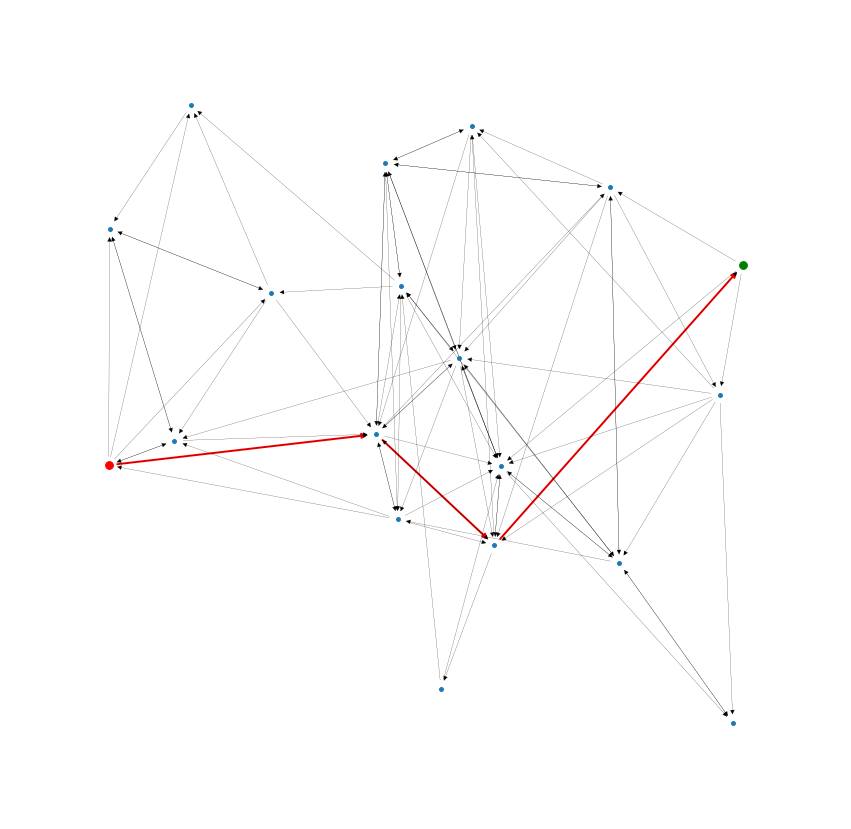

In [12]:
pp.figure( figsize = ( 15, 15 ) )

nx.draw_networkx_edges( G, pos, width = 2.0, edgelist = [ e for e in G.edges if abs( x[ e ].x ) > 1e-6 ], edge_color = 'r' )
nx.draw_networkx_nodes( G, pos, node_size = 15 )
nx.draw_networkx_edges( G, pos, width = 0.2 )

pp.scatter( pos[ o ][ 0 ], pos[ o ][ 1 ], c = 'r', s = 60, zorder = 10 )
pp.scatter( pos[ d ][ 0 ], pos[ d ][ 1 ], c = 'g', s = 60, zorder = 10 )

pp.margins( 0.1 )
pp.axis( 'off' )
pp.show()

Observe que

- Há um único caminho mínimo

- O resultado do problema relaxado é o mesmo que o anterior!

- As arestas não estão ordenadas de acordo com o caminho a ser percorrido!